In [ ]:
!pip install diffusers transformers torch accelerate safetensors -q

In [ ]:
import torch
from diffusers import AmusedPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

pipe = AmusedPipeline.from_pretrained(
    "amused/amused-512",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)
pipe = pipe.to(device)
print("✅ Modelo cargado")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--amused--amused-512/snapshots/6f3f309ba188a08e347bff9691a0ac791817ca97/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The AmusedPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


✅ Modelo cargado


In [ ]:
import os
os.makedirs("dinos_imagenes", exist_ok=True)

descripciones = {
    "Tanystrosuchus": "El Tanystrosuchus era un dinosaurio grande y robusto que vivió en el Jurásico, hace 250 millones de años. Era un animal con una larga cola y cuello.",
    "Lignaveusaurus": "Lignaveusaurus era un dinosaurio que vivió en el período Jurásico, hace 250 millones de años. Era un animal con una larga cola.",
    "Poinavenator": "El Poinavenator era un dinosaurio carnívoro del Jurásico con garras afiladas y una constitución ágil y veloz.",
    "Sinocalliopteryx": "El Sinocalliopteryx era un dinosaurio de la época Jurásica, con una larga cola emplumada y cuerpo esbelto.",
    "Araucanoraptor": "El Araucanoraptor era un dinosaurio que vivió en la era Jurásica, animal grande y robusto con garras poderosas.",
    "Macrophalangia": "El Macrophalangia fue un dinosaurio de tamaño grande con dedos elongados que vivió en el Jurásico.",
    "Saurophaganax": "El Saurophaganax fue un dinosaurio del Jurásico, gran depredador con una estructura ósea robusta.",
    "Becklespinax": "Becklespinax era un dinosaurio carnívoro con espinas dorsales prominentes que vivió en el Cretácico.",
    "Albertaceratops": "Albertaceratops vivió hace 125 millones de años en Alberta, con cuernos prominentes sobre los ojos.",
    "Mantellodon": "El Mantellodon era un dinosaurio herbívoro grande con dientes especializados que vivió en el Jurásico.",
}

for nombre, desc in descripciones.items():
    prompt = (
        f"A realistic dinosaur called {nombre}, {desc} "
        f"Prehistoric landscape background, detailed, high quality, "
        f"natural lighting, paleontology illustration style."
    )

    image = pipe(
        prompt,
        num_inference_steps=12,
        guidance_scale=7.5,
        height=512,
        width=512
    ).images[0]

    path = f"dinos_imagenes/{nombre}.png"
    image.save(path)
    print(f"✅ {nombre} guardado")

print("\n✅ 10 imágenes generadas")

  0%|          | 0/12 [00:00<?, ?it/s]

✅ Tanystrosuchus guardado


  0%|          | 0/12 [00:00<?, ?it/s]

✅ Lignaveusaurus guardado


  0%|          | 0/12 [00:00<?, ?it/s]

...

✅ Becklespinax guardado


  0%|          | 0/12 [00:00<?, ?it/s]

✅ Albertaceratops guardado


  0%|          | 0/12 [00:00<?, ?it/s]

✅ Mantellodon guardado

✅ 10 imágenes generadas


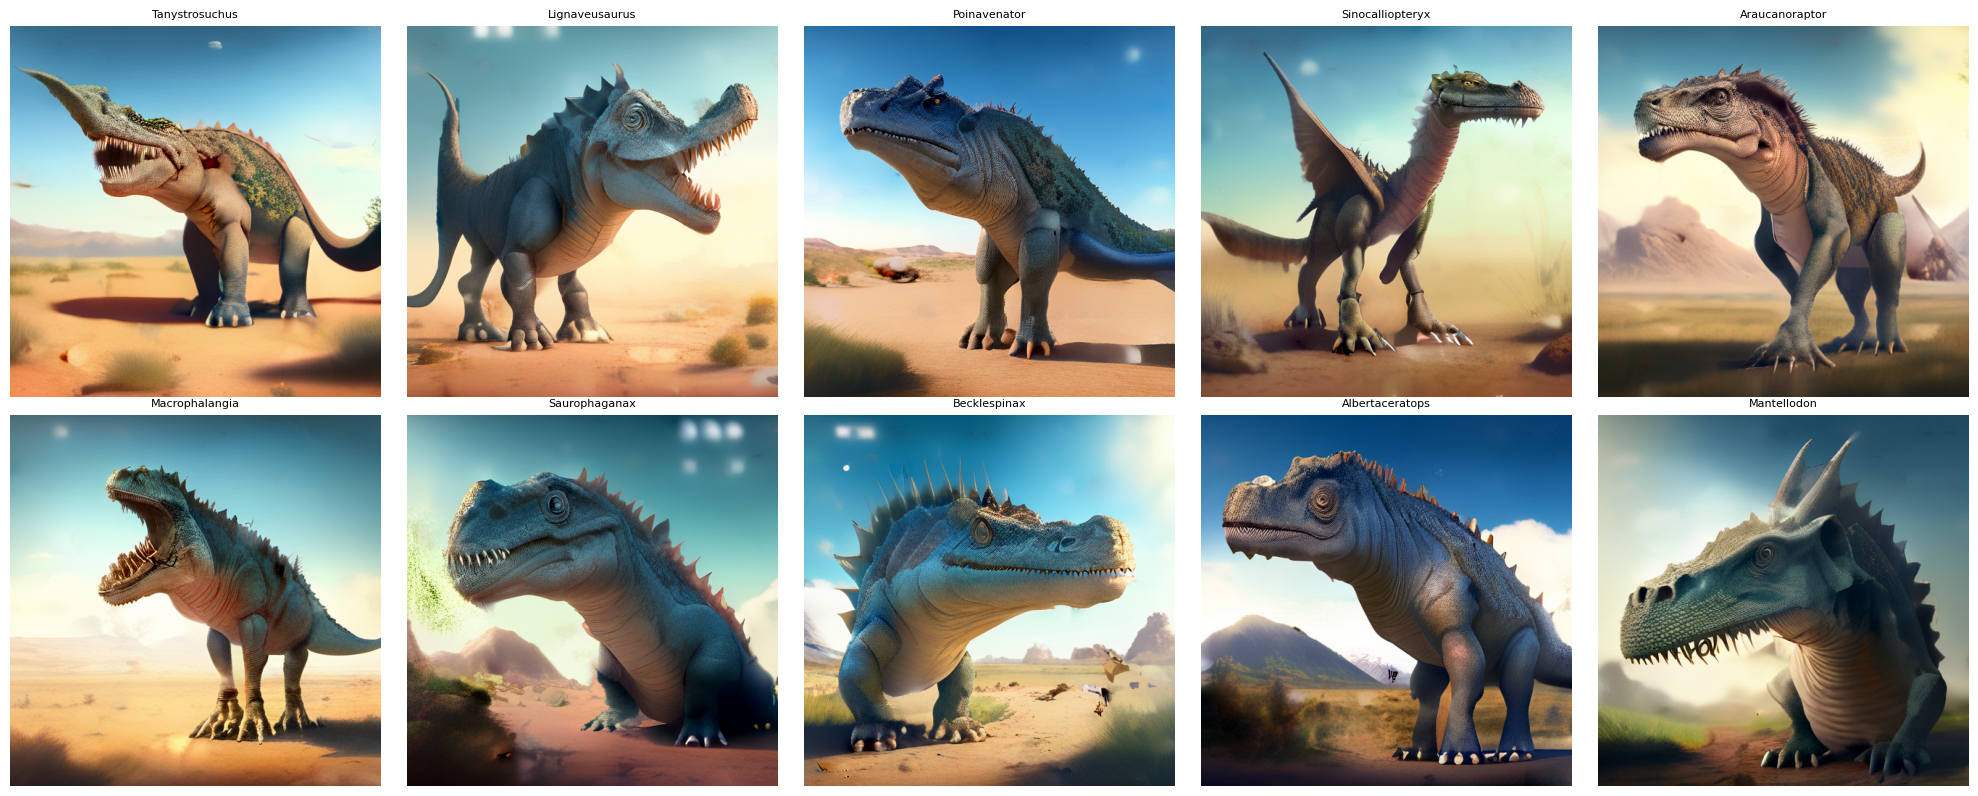

✅ Grid guardado


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

nombres = list(descripciones.keys())
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, nombre in zip(axes.flatten(), nombres):
    img = mpimg.imread(f"dinos_imagenes/{nombre}.png")
    ax.imshow(img)
    ax.set_title(nombre, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("dinos_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grid guardado")

In [ ]:
from google.colab import files
import zipfile

# Comprimir todas las imágenes
with zipfile.ZipFile("dinos_imagenes.zip", "w") as zf:
    for nombre in descripciones.keys():
        zf.write(f"dinos_imagenes/{nombre}.png")
    zf.write("dinos_grid.png")

files.download("dinos_imagenes.zip")
print("✅ Descargado")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargado


In [ ]:
!pip install pyngrok flask -q

from pyngrok import ngrok, conf

# Matar todos los túneles activos en este proceso
ngrok.kill()

# Configurar nuevo token
conf.get_default().auth_token = "NGROK_AUTHTOKEN_REMOVED"

# Levantar nuevo túnel
public_url = ngrok.connect(5000)
print(f"✅ Endpoint difusión: {public_url}")

import threading
threading.Thread(target=lambda: app.run(port=5000, use_reloader=False)).start()

✅ Endpoint difusión: NgrokTunnel: "https://darkening-slashed-sixfold.ngrok-free.dev" -> "http://localhost:5000"


Exception in thread Thread-7 (<lambda>):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_3517/3216756156.py", line 16, in <lambda>
NameError: name 'app' is not defined


In [ ]:
!pip install pyngrok flask -q

from flask import Flask, request, send_file
from pyngrok import ngrok, conf
import threading, io

app = Flask(__name__)

@app.route("/generate", methods=["POST"])
def generate():
    data = request.json
    prompt = data.get("prompt", "a dinosaur")
    image = pipe(prompt, num_inference_steps=12,
                 guidance_scale=7.5, height=512, width=512).images[0]
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    buf.seek(0)
    return send_file(buf, mimetype="image/png")

ngrok.kill()
conf.get_default().auth_token = "NGROK_AUTHTOKEN_REMOVED"
public_url = ngrok.connect(5000)
print(f"✅ Endpoint difusión: {public_url}")

threading.Thread(target=lambda: app.run(port=5000, use_reloader=False)).start()

✅ Endpoint difusión: NgrokTunnel: "https://darkening-slashed-sixfold.ngrok-free.dev" -> "http://localhost:5000"




-------------------------------------------------------------------------------



In [ ]:
from pyngrok import ngrok, conf

# Matar todos los túneles activos en este proceso
ngrok.kill()

# Configurar nuevo token
conf.get_default().auth_token = "NGROK_AUTHTOKEN_REMOVED"

# Levantar nuevo túnel
public_url = ngrok.connect(5000)
print(f"✅ Endpoint difusión: {public_url}")

threading.Thread(target=lambda: app.run(port=5000, use_reloader=False)).start()

ModuleNotFoundError: No module named 'pyngrok'

In [ ]:
ngrok.set_auth_token("NGROK_AUTHTOKEN_REMOVED")

public_url = ngrok.connect(5000)
print(f"✅ Endpoint difusión: {public_url}")

threading.Thread(target=lambda: app.run(port=5000)).start()

In [ ]:
import requests, io
from PIL import Image

response = requests.post(
    "https://darkening-slashed-sixfold.ngrok-free.dev/generate",
    json={"prompt": "a friendly dinosaur in a prehistoric jungle"},
    headers={"ngrok-skip-browser-warning": "true"}
)

img = Image.open(io.BytesIO(response.content))
img.show()
print(f"✅ Endpoint funcionando — status: {response.status_code}")

In [ ]:
import torch
torch.save(model.state_dict(), "dino_rnn_model.pth")

from google.colab import files
files.download("dino_rnn_model.pth")